# Proteins and LLMs

Author: Umberto Michelucci, umberto.michelucci@hslu.ch

Protein language models treat amino-acid sequences like sentences:

    MKTFFVAGVILALAG

is treated similarly to:

    "The cat sits on the mat"

The model learns:

- patterns
- structure
- evolutionary relationships
- biochemical meaning

A very intuitive minimal demo is:

similar protein sequences have similar embeddings
embeddings cluster biologically related proteins
proteins can be compared like text

This is conceptually identical to word embeddings.

A good educational model is ESM2 by Meta AI (https://github.com/facebookresearch/esm?utm_source=chatgpt.com)

Content:
- loads a protein language model
- embeds a few protein sequences
- reduces embeddings to 2D with PCA
- visualizes similarity

## Protein Embeddings with a Protein Language Model

Protein language models treat amino-acid sequences like text.

Example protein sequence:

    MKTFFVAGVILALAG

The model converts each sequence into an embedding vector.

Proteins with similar biological properties often end up close together
in embedding space.

This is similar to:
- king ↔ queen
- apple ↔ banana

in word embeddings.

## Parallel with Text

NLP:
words → embeddings → meaning

Biology:
protein sequences → embeddings → biological meaning

In [2]:
#!pip install transformers torch scikit-learn matplotlib

In [3]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

/Users/umbertomichelucci/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Protein Model

In [4]:
# Small protein language model

model_name = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 21379.19it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
proteins = {
    "Hemoglobin_A": "MVLSPADKTNVKAAW",
    "Hemoglobin_B": "MVHLTPEEKSAVTAL",
    "Insulin": "MALWMRLLPLLALLA",
    "Collagen": "GLPGPPGPPGPPGPP",
    "Random_like": "AAAAAAAAAAAAAAA"
}

## Create Embeddings

In [6]:
def protein_embedding(sequence):

    inputs = tokenizer(sequence, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # Mean pooling
    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding[0].numpy()

In [7]:
names = []
embeddings = []

for name, sequence in proteins.items():

    emb = protein_embedding(sequence)

    names.append(name)
    embeddings.append(emb)

embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

Embedding shape: (5, 320)


In [8]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)

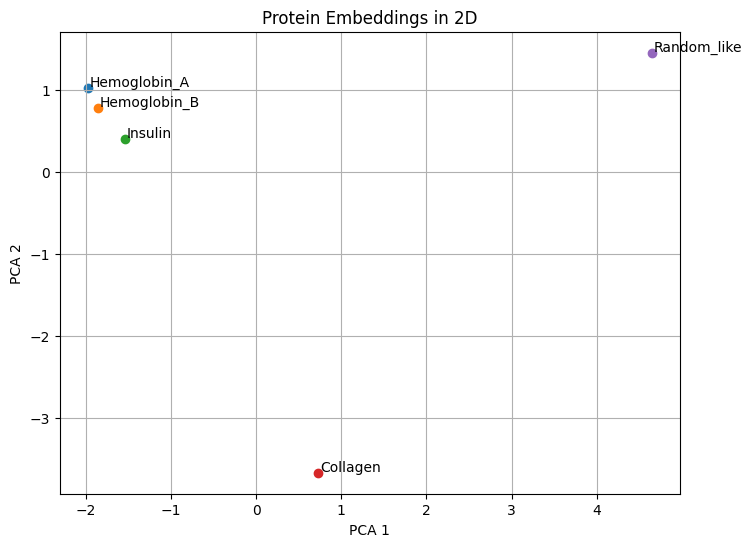

In [9]:
plt.figure(figsize=(8,6))

for i, name in enumerate(names):

    x = reduced[i,0]
    y = reduced[i,1]

    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, name)

plt.title("Protein Embeddings in 2D")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.grid(True)

plt.show()

## What happened?

The protein language model converted each amino-acid sequence into a vector.

Proteins with similar biochemical or evolutionary properties tend to
produce similar embeddings.

We then used PCA to reduce the embeddings to 2 dimensions.

This allows us to visualize protein similarity geometrically.

This is one of the foundations of modern AI approaches in:
- protein discovery
- protein classification
- structure prediction
- drug discovery
- synthetic biology